# Machine Learning and Analytics

## Final Project

### Marianna Kanellaki - S-001081

### Part 2: Classification

Experiments using EM ang K-means. I used code from the lectures and adapted it to support multi-dimensional data. I added scaling for the features and PCA for the clustering visualization. For the centroids I used random points from the dataset. TODO

Setup

In [115]:
import warnings
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.exceptions import ConvergenceWarning

In [116]:
from naiveBayes import *

In [117]:
edible_df = pd.read_json('../data/s-001081_edible.json')
edible_df

,leaf_shape,petal_colour,berry_colour,edible
0,lanceolate,white,grey,False
1,lanceolate,white,blue,True
2,lanceolate,white,blue,True
3,ovate,pink,green,False
4,lanceolate,white,green,False
...,...,...,...,...
495,ovate,pink,purple,True
496,lanceolate,white,green,False
497,ovate,white,purple,False
498,lanceolate,white,green,False


In [118]:
edible_df.isna().sum()

leaf_shape      0
petal_colour    0
berry_colour    0
edible          0
dtype: int64

#### 2.1 Edibility Rules

*Deriving edibility rules using a Decision Tree classifier from sklearn*

In [119]:
X_raw = edible_df[['leaf_shape', 'petal_colour', 'berry_colour']]
y = edible_df['edible']

X_encoded = pd.get_dummies(X_raw)

In [120]:
clf = DecisionTreeClassifier(max_depth=4, criterion='entropy', random_state=42)
clf.fit(X_encoded, y)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'entropy'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",4
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

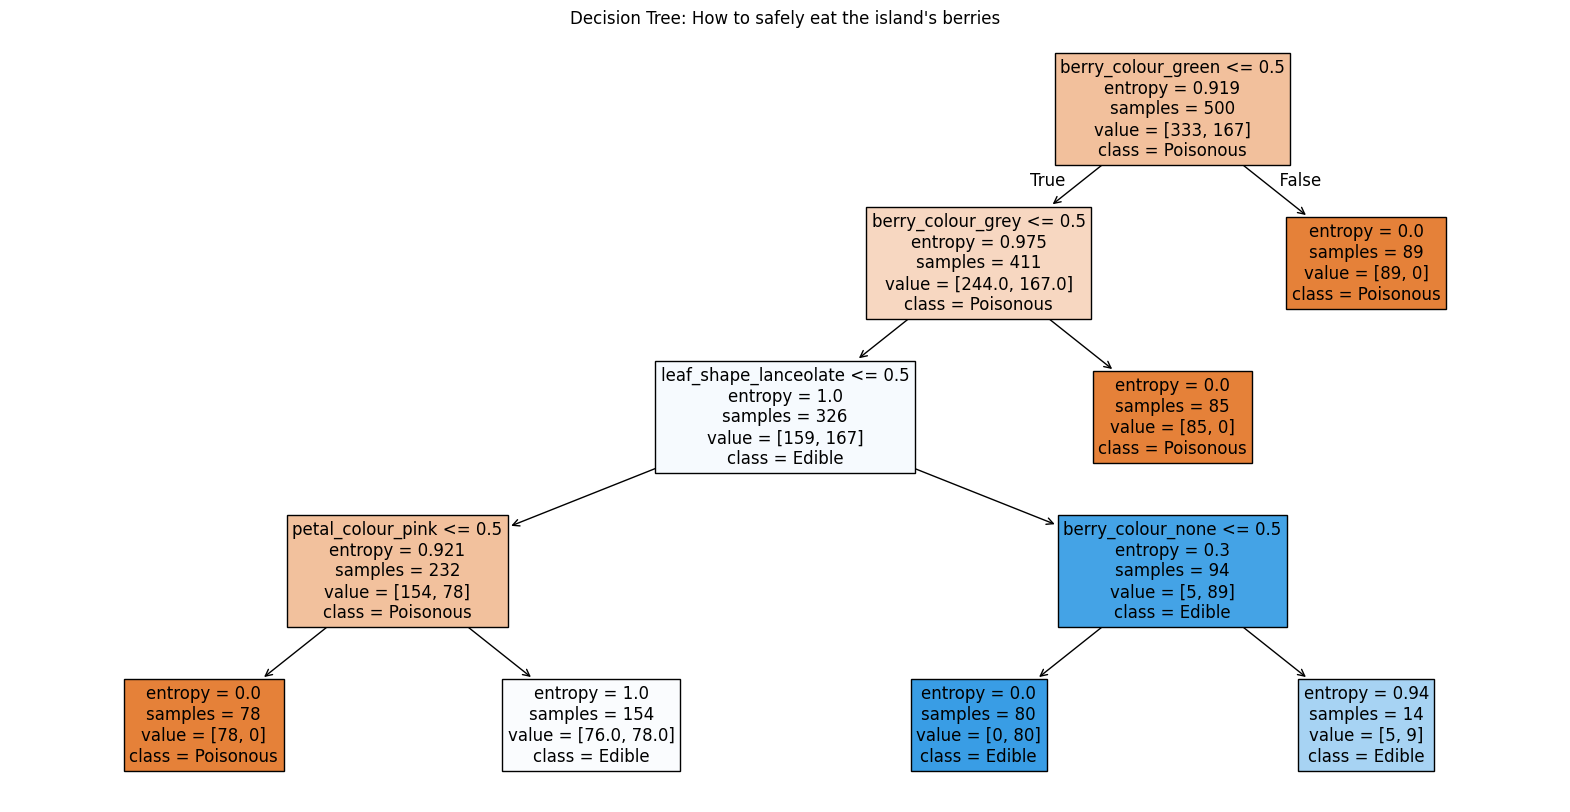

In [121]:
feature_names = list(X_encoded.columns)

plt.figure(figsize=(20,10))
plot_tree(clf, 
          feature_names=feature_names, 
          class_names=['Poisonous', 'Edible'], 
          filled=True, 
          fontsize=12)
plt.title("Decision Tree: How to safely eat the island's berries")
plt.show()

After analyzing the new data through a Decision Tree Classifier, categorical patterns emerge that define the berries' safety. Edibility is not determined by a single trait, but by a set of rules. Petal Color serves as the most significant indicator, carrying the most information about it. Some petal colors are toxic regardless of the other characteristics of the berry (e.g. green and gray). In cases where petal colors are shared across species, the model utilizes leaf shape as a secondary discriminant. The nature of the Decision Tree allows the translation of the classifier's tree into a set of rules for berry edibility on the island.

#### 2.2 Species Classification

*Using different classifiers and comparing them to classify the species on the new notes*

In [122]:
species_df = pd.read_json('../data/s-001081_species.json')
species_df

,leaf_shape,petal_colour,berry_colour,species
0,lanceolate,white,grey,berrius elephas
1,lanceolate,white,blue,berrius actius
2,lanceolate,white,blue,berrius actius
3,ovate,pink,green,berrius boethiae
4,lanceolate,white,green,berrius elephas
...,...,...,...,...
495,ovate,pink,purple,berrius boethiae
496,lanceolate,white,green,berrius actius
497,ovate,white,purple,berrius codiae
498,lanceolate,white,green,berrius actius


In [123]:
X_raw = species_df[['leaf_shape', 'petal_colour', 'berry_colour']]
y = species_df['species']

X_encoded = pd.get_dummies(X_raw)

X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)
classes = np.unique(y)

In [124]:
# performs logistic regression, KNN, SVM, Random Forest, and Decision Tree classification
results = {}
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "KNN (k=5)": KNeighborsClassifier(n_neighbors=5),
    "SVM (RBF Kernel)": SVC(kernel='rbf'),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Decision Tree": DecisionTreeClassifier(max_depth=10, random_state=42)
}

for name, model in models.items():
    model.fit(X_train, y_train)
    results[name] = model.predict(X_test)

In [125]:
# performs Naive Bayes classification
train_data_nb = np.column_stack((X_train.values, y_train.values))
g_dict = naiveBayes(classes, binary_learner, binary_parameterised_function, train_data_nb)

all_class_likelihoods = []
for class_value in classes:
    class_func = g_dict[class_value]
    likelihood = class_func(X_test.values) 
    all_class_likelihoods.append(likelihood)

likelihood_matrix = np.hstack(all_class_likelihoods)
nb_pred_indices = np.argmax(likelihood_matrix, axis=1)
results["Naive Bayes"] = classes[nb_pred_indices]

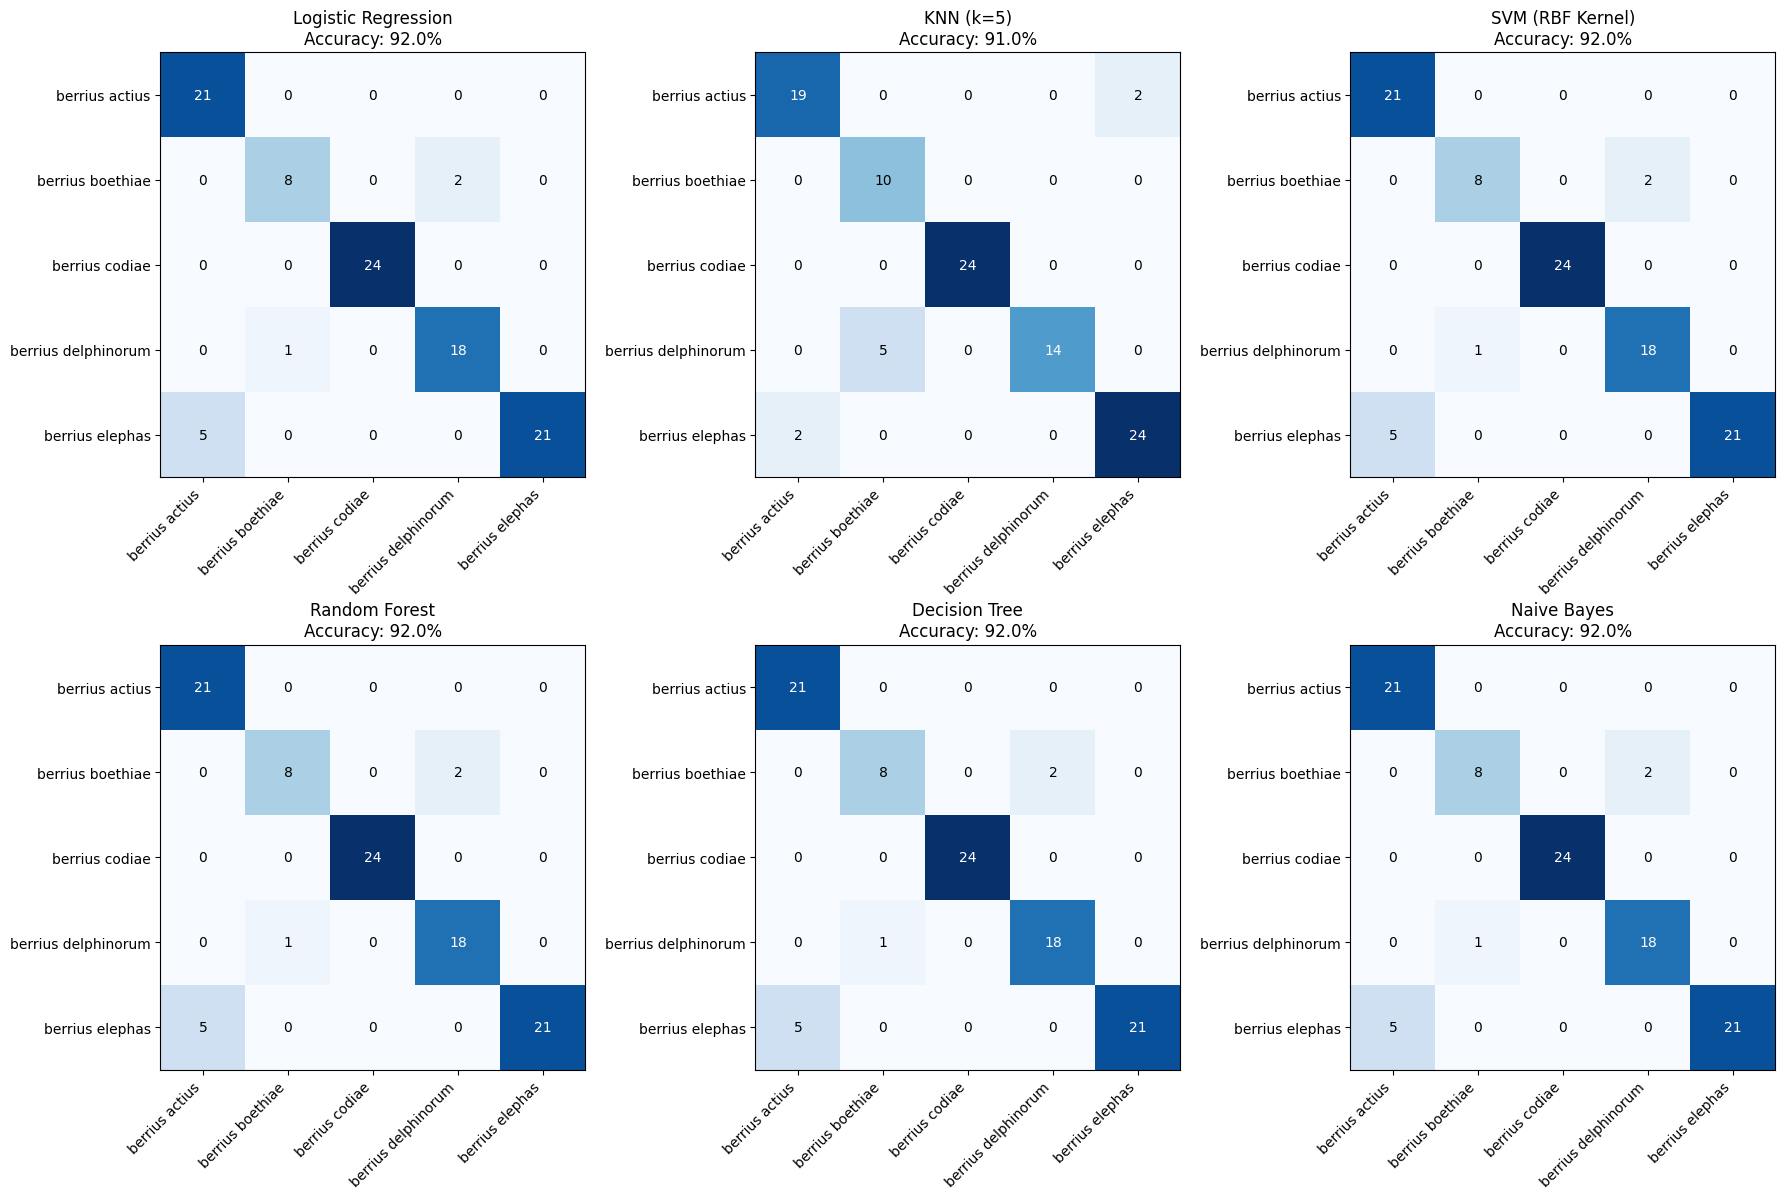

In [139]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for i, (name, y_pred) in enumerate(results.items()):
    acc = accuracy_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred, labels=classes)
    
    im = axes[i].imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    axes[i].set_title(f"{name}\nAccuracy: {acc*100:.1f}%")
    
    tick_marks = np.arange(len(classes))
    axes[i].set_xticks(tick_marks)
    axes[i].set_xticklabels(classes, rotation=45, ha='right')
    axes[i].set_yticks(tick_marks)
    axes[i].set_yticklabels(classes)
    
    thresh = cm.max() / 2.
    for row in range(cm.shape[0]):
        for col in range(cm.shape[1]):
            axes[i].text(col, row, format(cm[row, col], 'd'),
                         ha="center", va="center",
                         color="white" if cm[row, col] > thresh else "black")

plt.tight_layout()
plt.show()

All classifiers managed to distinguish the berry species very well, showing an accuracy of 91-92%. All of them except KNN have the same results and missclassify the same species. KNN seems to have more sensitivity in under represented classes, confusing more the berrius boelithiae and berrius delphinorum that have less samples. Overall, it is possible to distinguish the species given our information.

#### 2.3 Species & Edibility

In [140]:
leaf_df = pd.read_json('../data/s-001081_leaf.json')
leaf_df

,age,height,soil_quality,leaf_shape,leaf_size,edible,species
0,7.827582,239.007710,4.101307,lanceolate,24.510278,False,berrius elephas
1,7.946372,165.247307,3.105685,lanceolate,27.694587,True,berrius actius
2,3.572540,224.763124,5.540744,lanceolate,45.625918,True,berrius actius
3,2.290430,69.530241,3.790448,ovate,11.864775,False,berrius boethiae
4,1.907052,45.883920,3.215510,lanceolate,18.736034,False,berrius elephas
...,...,...,...,...,...,...,...
495,6.111563,205.911846,4.052288,ovate,14.665505,True,berrius boethiae
496,1.297815,33.783400,3.130843,lanceolate,25.466863,False,berrius actius
497,7.127454,230.943919,4.123064,ovate,26.944936,False,berrius codiae
498,1.185752,37.092050,3.581669,lanceolate,26.458160,False,berrius actius


In [141]:
petal_df = pd.read_json('../data/s-001081_petal.json')
petal_df

,age,height,soil_quality,petal_colour,petal_size,edible,species
0,7.827582,239.007710,4.101307,white,3.118933,False,berrius elephas
1,7.946372,165.247307,3.105685,white,1.259286,True,berrius actius
2,3.572540,224.763124,5.540744,white,2.319500,True,berrius actius
3,2.290430,69.530241,3.790448,pink,3.159112,False,berrius boethiae
4,1.907052,45.883920,3.215510,white,2.477067,False,berrius elephas
...,...,...,...,...,...,...,...
495,6.111563,205.911846,4.052288,pink,3.130601,True,berrius boethiae
496,1.297815,33.783400,3.130843,white,1.101837,False,berrius actius
497,7.127454,230.943919,4.123064,white,2.584270,False,berrius codiae
498,1.185752,37.092050,3.581669,white,1.402115,False,berrius actius


In [142]:
berry_df = pd.read_json('../data/s-001081_berry.json')
berry_df

,age,height,soil_quality,berry_colour,berry_size,edible,species
0,7.827582,239.007710,4.101307,grey,7.959125,False,berrius elephas
1,7.946372,165.247307,3.105685,blue,8.569603,True,berrius actius
2,3.572540,224.763124,5.540744,blue,11.523105,True,berrius actius
3,2.290430,69.530241,3.790448,green,6.010535,False,berrius boethiae
4,1.907052,45.883920,3.215510,green,6.506491,False,berrius elephas
...,...,...,...,...,...,...,...
495,6.111563,205.911846,4.052288,purple,6.076126,True,berrius boethiae
496,1.297815,33.783400,3.130843,green,7.526041,False,berrius actius
497,7.127454,230.943919,4.123064,purple,9.737714,False,berrius codiae
498,1.185752,37.092050,3.581669,green,9.546730,False,berrius actius


In [143]:
comparison_results = []

trait_labels = ["Leaf Only", "Petal Only", "Berry Only"]
dataframes = [leaf_df, petal_df, berry_df]

warnings.filterwarnings("ignore", category=ConvergenceWarning)
for label, df in zip(trait_labels, dataframes):
    y_e = df['edible']
    y_s = df['species']

    X_p = df.drop(columns=['edible', 'species'])
    X_p = pd.get_dummies(X_p)
    
    X_train, X_test, y_train_e, y_test_e = train_test_split(X_p, y_e, test_size=0.2, random_state=42)
    _, _, y_train_s, y_test_s = train_test_split(X_p, y_s, test_size=0.2, random_state=42)

    # mapping for species and edibility
    mapping_subset = pd.DataFrame({'species': y_train_s, 'edible': y_train_e})
    local_species_to_edible = mapping_subset.groupby('species')['edible'].first().to_dict()

    for name, model in models.items(): # using 5 sklearn models from above
        # edibility classification
        model.fit(X_train, y_train_e)
        e_preds = model.predict(X_test)
        
        # species classification
        model.fit(X_train, y_train_s)
        s_preds = model.predict(X_test)

        # species classification mapped to edibility
        m_preds = [local_species_to_edible[s] for s in s_preds]
        
        comparison_results.append({
            "Trait": label,
            "Model": name,
            "Edibility_Acc": accuracy_score(y_test_e, e_preds),
            "Mapped_Acc": accuracy_score(y_test_e, m_preds),
            "Species_Acc": accuracy_score(y_test_s, s_preds),
        })

    # using naive bayes
    classes_s = np.unique(y_train_s)
    classes_e = np.unique(y_train_e)

    # edibility classification
    train_data_e = np.column_stack((X_train.values, y_train_e.values))
    g_e = naiveBayes(classes_e, binary_learner, binary_parameterised_function, train_data_e)
    lh_e = np.hstack([g_e[c](X_test.values) for c in classes_e])
    nb_e_preds = classes_e[np.argmax(lh_e, axis=1)]

    # species classification
    train_data_s = np.column_stack((X_train.values, y_train_s.values))
    g_s = naiveBayes(classes_s, binary_learner, binary_parameterised_function, train_data_s)
    lh_s = np.hstack([g_s[c](X_test.values) for c in classes_s])
    nb_s_preds = classes_s[np.argmax(lh_s, axis=1)]
    
    # species classification mapped to edibility
    nb_m_preds = [local_species_to_edible[s] for s in nb_s_preds]

    comparison_results.append({
        "Trait": label,
        "Model": "Naive Bayes",
        "Edibility_Acc": accuracy_score(y_test_e, nb_e_preds),
        "Mapped_Acc": accuracy_score(y_test_e, nb_m_preds),
        "Species_Acc": accuracy_score(y_test_s, nb_s_preds),
    })

results_df = pd.DataFrame(comparison_results)

In [144]:
def plot_partial_data_accuracies(trait):
    subset = results_df[results_df['Trait'] == trait]
    
    x = np.arange(len(subset['Model']))
    width = 0.25
    
    plt.figure(figsize=(12, 6))
    plt.bar(x - width/2, subset['Edibility_Acc'], width, label='Edibility Classification', color='#2ECC71')
    plt.bar(x + width/2, subset['Mapped_Acc'], width, label='Species to Edibility Mapping', color='#E74C3C')
    plt.bar(x + width*1.5, subset['Species_Acc'], width, label='Species Classification', color='#FFC000')

    plt.title(f'Survival Strategy Effectiveness: {trait}', fontsize=14, fontweight='bold')
    plt.ylabel('Accuracy')
    plt.xticks(x, subset['Model'], rotation=15)
    plt.ylim(0, 1.1)
    plt.legend(loc='upper right')
    plt.yticks(np.arange(0, 1.1, 0.1))
    plt.grid(axis='y', linestyle='--', alpha=0.6)
    
    plt.tight_layout()
    plt.show()

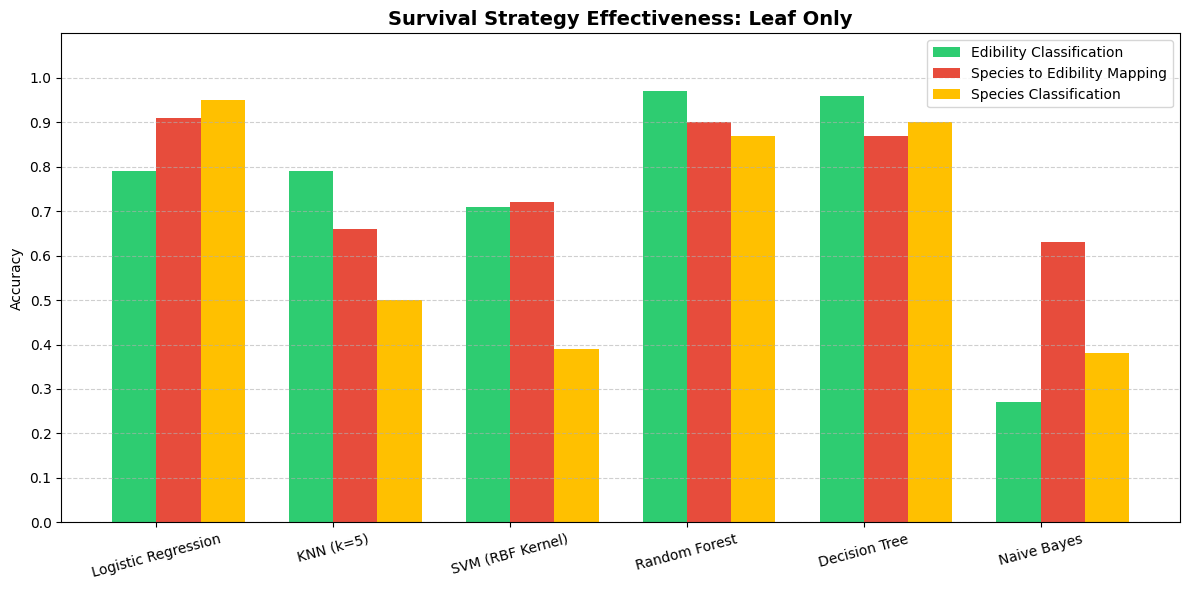

In [145]:
plot_partial_data_accuracies("Leaf Only")

In [146]:
results_df[results_df['Trait'] == 'Leaf Only']

,Trait,Model,Edibility_Acc,Mapped_Acc,Species_Acc
0,Leaf Only,Logistic Regression,0.79,0.91,0.95
1,Leaf Only,KNN (k=5),0.79,0.66,0.50
2,Leaf Only,SVM (RBF Kernel),0.71,0.72,0.39
3,Leaf Only,Random Forest,0.97,0.90,0.87
4,Leaf Only,Decision Tree,0.96,0.87,0.90
5,Leaf Only,Naive Bayes,0.27,0.63,0.38


Using only the leaf characteristics (along with the general known features), overall we can successfully distinguish the berry edibility and species. Half of the models used perform better when classifying the edibility directly, while the other half performed better when classifying the species first and then mapping that result to the edibility. The Naive Bayes algorithm has a huge difference between these experiments, and performs much better when predicting the species. 

The best accuracies achieved are: 

- **Edibility:** *97%* using *Random Forests*
- **Species mapped to Edibility:** *91%* using *Logistic Regression*
- **Species:** *95%* using *Logistic Regression*

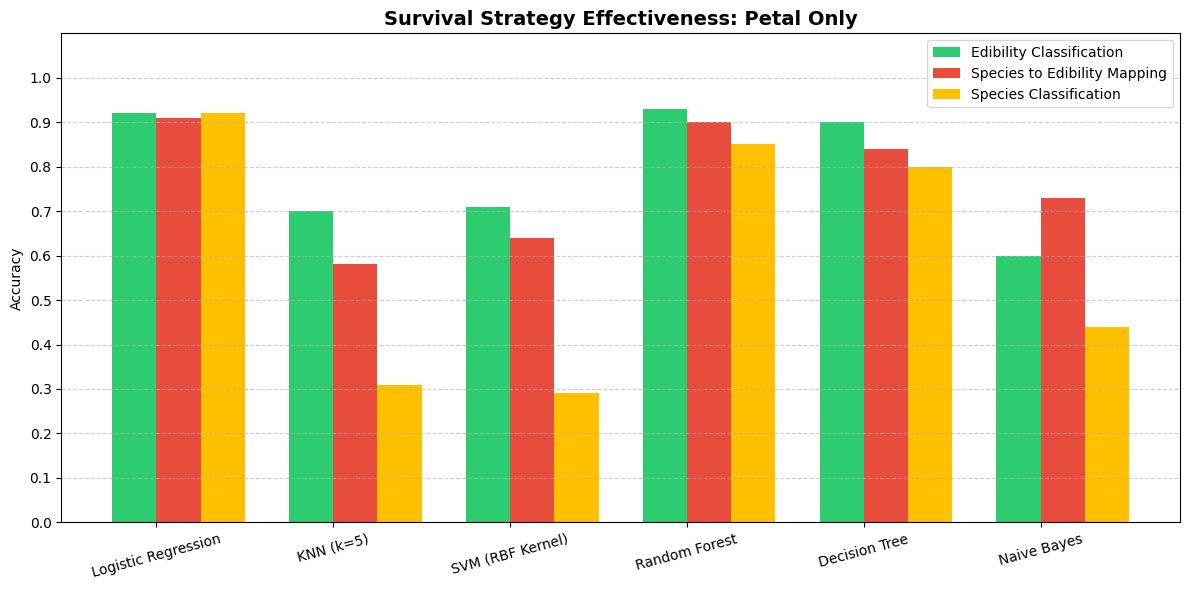

In [147]:
plot_partial_data_accuracies("Petal Only")

In [148]:
results_df[results_df['Trait'] == 'Petal Only']

,Trait,Model,Edibility_Acc,Mapped_Acc,Species_Acc
6,Petal Only,Logistic Regression,0.92,0.91,0.92
7,Petal Only,KNN (k=5),0.70,0.58,0.31
8,Petal Only,SVM (RBF Kernel),0.71,0.64,0.29
9,Petal Only,Random Forest,0.93,0.90,0.85
10,Petal Only,Decision Tree,0.90,0.84,0.80
11,Petal Only,Naive Bayes,0.60,0.73,0.44


Using only the petal characteristics (along with the general known features), overall we can successfully distinguish the berry edibility and species. All models used perform better when classifying the edibility directly, rather than using the mapping. Naive Bayes again performs better when classifying the species.

The best accuracies achieved are: 

- **Edibility:** *93%* using *Random Forests*
- **Species mapped to Edibility:** *91%* using *Logistic Regression*
- **Species:** *92%* using *Logistic Regression*

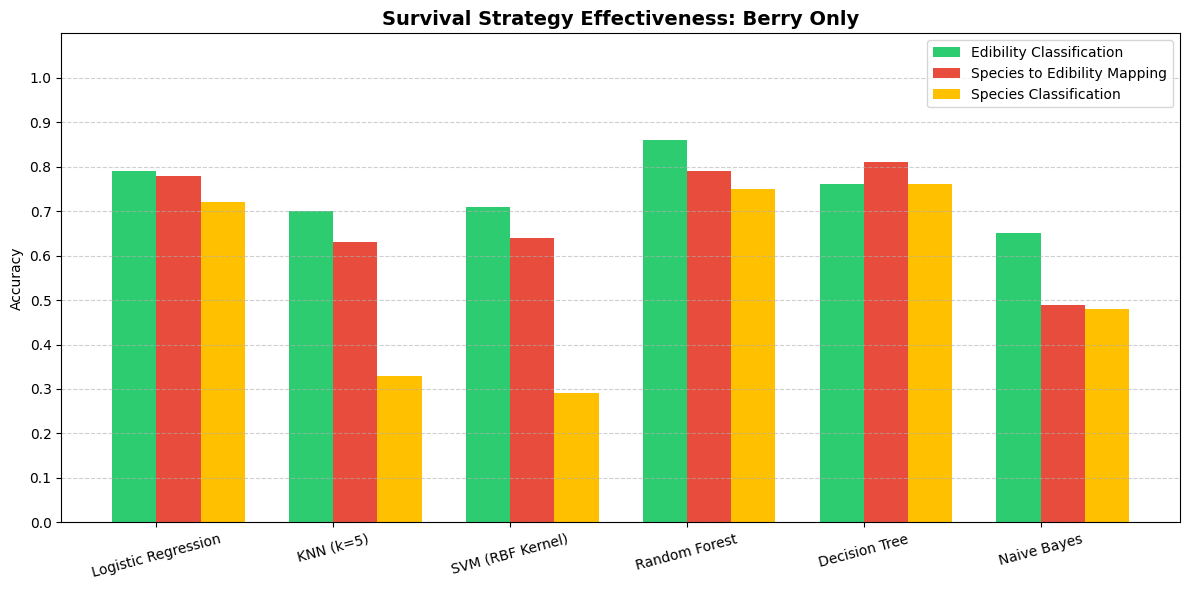

In [149]:
plot_partial_data_accuracies("Berry Only")

In [150]:
results_df[results_df['Trait'] == 'Berry Only']

,Trait,Model,Edibility_Acc,Mapped_Acc,Species_Acc
12,Berry Only,Logistic Regression,0.79,0.78,0.72
13,Berry Only,KNN (k=5),0.70,0.63,0.33
14,Berry Only,SVM (RBF Kernel),0.71,0.64,0.29
15,Berry Only,Random Forest,0.86,0.79,0.75
16,Berry Only,Decision Tree,0.76,0.81,0.76
17,Berry Only,Naive Bayes,0.65,0.49,0.48


Using only the berry characteristics (along with the general known features), overall we can successfully distinguish the berry edibility and species. Almost all models used perform better when classifying the edibility directly. The decision tree classified better the species than the edibility, and showed an equal accuracy for classifying the edibility directly and using species then mapping.

The best accuracies achieved are: 

- **Edibility:** *86%* using *Random Forests*
- **Species mapped to Edibility:** *81%* using *Decision Tree*
- **Species:** *76%* using *Logistic Regression*

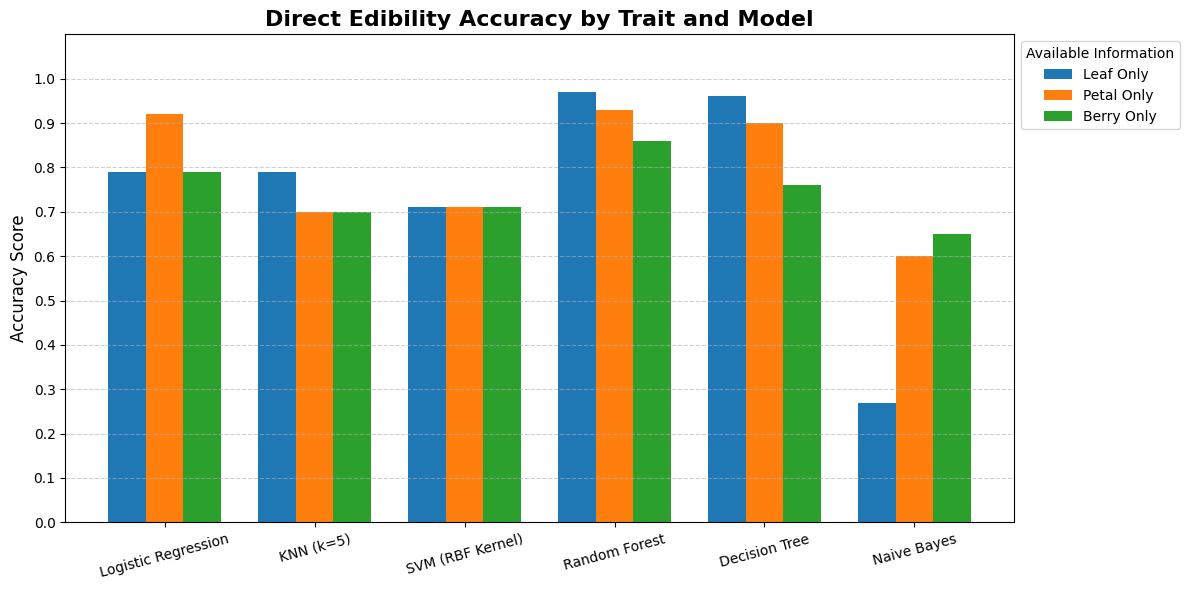

In [151]:
traits = ["Leaf Only", "Petal Only", "Berry Only"]
models_list = results_df['Model'].unique()

plt.figure(figsize=(12, 6))
x = np.arange(len(models_list))
width = 0.25

for i, trait in enumerate(traits):
    subset = results_df[results_df['Trait'] == trait]
    plt.bar(x + (i-1)*width, subset['Edibility_Acc'], width, label=trait)

plt.yticks(np.arange(0, 1.1, 0.1))
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.title('Direct Edibility Accuracy by Trait and Model', fontsize=16, fontweight='bold')
plt.ylabel('Accuracy Score', fontsize=12)
plt.xticks(x)
plt.xticks(x, subset['Model'], rotation=15)
plt.ylim(0, 1.1)
plt.legend(title="Available Information", loc='upper left', bbox_to_anchor=(1, 1))

plt.tight_layout()
plt.show()

In conclusion, these experiments demonstrate that while the berry species on the island are highly distinguishable, the most effective survival strategy depends on the type of information available and the complexity of the analytical model used. When limited to a single characteristic (leaves, petals, or berries) direct edibility classification consistently outperforms the species to edibility mapping. Specifically, in the leaf only scenario, Random Forest achieved a peak accuracy of 97% for direct edibility, whereas the mapping strategy showed an accuracy of 90%.

For linear or probabilistic models like Logistic Regression and Naive Bayes, identifying the species first improves the final edibility predictions. The leaf emerged as the most reliable trait for all forms of identification, while berries proved to be the least reliable, with accuracy dropping as low as 76% for species identification. 

Ultimately, the results suggest that a survivor is safest relying on a direct edibility assessment of leaf characteristics using ensemble-based logic.